In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import LeaveOneOut, KFold, cross_val_predict,RandomizedSearchCV,GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline,make_pipeline
from xgboost import XGBRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern, ConstantKernel as C,DotProduct, RationalQuadratic
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# 容错导入SHAP
try:
    import shap
except Exception as e:
    print(f"SHAP导入失败: {e}")
    shap = None

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei'] # 显示中文
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 初始准备工作
# 1.读取清洗好的数据
file_path = "Final_Features_Ultimate_all_deletion.csv" 
df = pd.read_csv(file_path)

In [14]:
# 2. 定义特征组 (严格对齐新版 CSV 列名)

# A. 力学特征组 (用于预测 Strength, Elongation)
# 包含：用量层 + 身份层 + 机理层
features_mech = [
    # --- 1. 用量层 (Dosage) ---
    'X1_Soft_Content',      # 软段含量 (原 X1_SoftSeg)
    'X2_DA_Content',        # DA单体含量
    'X3_Hard_Content',      # 硬段含量 (原 X3_HardSeg)
    'X4_R_Ratio',           # 异氰酸酯指数
    'X5_Add_Crosslink',     # 额外非DA交联剂含量 (原 X5_Crosslink)
    
    # --- 2. 身份层 (Identity) ---
    'DA_Linker_Type',       # 0=无, 1=糠胺, 2=糠醇 (替代原来的 DA_KA/KC)
    'Network_Topology',     # 0=主链, 1=侧链 (替代原来的 cross_class)
    'Polyol_Class',         # 0=聚醚, 1=聚酯 (替代 Polyol_Type)
    'Iso_Class',            # 0=脂肪族, 1=芳香族 (替代 Iso_Type 1-5分)
    
    # --- 3. 机理层 (Mechanism) ---
    'Soft_Mw',              # 软段分子量
    'Constraint_Factor',    # 冻结因子 (关键!)
    'Hard_Symmetry',        # 硬段对称性
    'Soft_Cryst',           # 软段结晶性
    'Synergy_Feature'       # 结晶协同因子
    # 注意：Extender_Class、Add_Crosslinker_Flag 已删除（与 X5_Add_Crosslink 完全相关 r=1.0）
]

# B. 愈合特征组 (用于预测 Healing Efficiency)
# 包含：力学特征 + 工艺参数 (温度、时间)
features_heal = features_mech + ['healing_temperature', 'healing_time']

# 3. 二次清洗 (逻辑保持不变)
def get_clean_data(target_col, feature_cols, df):
    """
    清洗数据：仅保留目标值和特征值都不为空的行
    """
    # 检查列是否存在，防止报错
    missing_cols = [c for c in feature_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"以下特征在 CSV 中找不到，请检查列名拼写: {missing_cols}")

    # 剔除空值
    data = df.dropna(subset=[target_col] + feature_cols).copy()
    
    X = data[feature_cols].values
    y = data[target_col].values
    
    return X, y

# 4. 定义评估函数 (逻辑保持不变)
def evaluate_model(model, X, y, task_name="Task"):
    # 使用 LOOCV (留一法) 适合小样本 (<100)
    cv = LeaveOneOut() 
    
    # 预测
    # 注意：如果使用 GP 或 NeuralNet，建议在 Pipeline 里加 StandardScaler
    y_pred = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)
    
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    return r2, rmse, y_pred

# 5. 检查与验证
print("特征组定义完毕！")
print(f"力学模型特征数: {len(features_mech)}")
print(f"自愈合模型特征数: {len(features_heal)}")

# 尝试打印前5行看看是否报错 (检查列名匹配)
try:
    print("\n特征数据概览 (前5行):")
    print(df[features_mech].head())
    print(f"\n有效总样本数: {len(df)}")
except KeyError as e:
    print(f"\n❌ 错误：CSV列名不匹配！请检查上一轮生成的 CSV 文件。报错列名: {e}")
except NameError:
    print("\n⚠️ 提示：df 尚未加载，请先读取 CSV 文件。")

特征组定义完毕！
力学模型特征数: 14
自愈合模型特征数: 16

特征数据概览 (前5行):
   X1_Soft_Content  X2_DA_Content  X3_Hard_Content  X4_R_Ratio  \
0           0.6607         0.1924           0.1469      0.5000   
1           0.6825         0.1658           0.1517      0.5333   
2           0.4880         0.0800           0.4320      0.9677   
3           0.6651         0.0000           0.3349      1.3333   
4           0.5592         0.0000           0.4078      1.0000   

   X5_Add_Crosslink  DA_Linker_Type  Network_Topology  Polyol_Class  \
0             0.000               2                 0             1   
1             0.000               2                 0             1   
2             0.000               2                 1             0   
3             0.000               0                 0             0   
4             0.033               0                 0             0   

   Iso_Class  Soft_Mw  Constraint_Factor  Hard_Symmetry  Soft_Cryst  \
0          0   2000.0             0.0001              0 

In [ ]:
# ============================================
# Pearson 相关性分析（证明特征设计的合理性）
# ============================================
"""
目的：
1. 证明 Trade-off 的客观存在（拉伸强度 vs 自愈合效率）
2. 证明基础特征与性能是非线性关系（线性相关系数低）
3. 检查特征冗余（多重共线性）
"""

# 准备分析数据：特征 + 三个目标性能
targets = ['tensile_strength', 'elongation', 'healing_eff']

# 对于力学性能分析，使用力学特征
# 注意：healing_eff 样本数较少，需要单独处理
print("="*80)
print("Pearson 相关性分析")
print("="*80)

# 方案1：分析力学性能的相关性（tensile_strength 和 elongation）
print("\n[方案1] 力学性能相关性分析（特征 + tensile_strength + elongation）")
print("-"*80)

# 获取有效数据（排除缺失值）
mech_targets = ['tensile_strength', 'elongation']
mech_data = df[features_mech + mech_targets].dropna()

print(f"有效样本数: {len(mech_data)}")
print(f"分析维度: {len(features_mech)} 特征 + {len(mech_targets)} 目标 = {len(features_mech) + len(mech_targets)} 维")

# 计算 Pearson 相关系数矩阵
corr_matrix_mech = mech_data.corr(method='pearson')

# 提取关键信息：两个性能之间的相关性
corr_tensile_elongation = corr_matrix_mech.loc['tensile_strength', 'elongation']
print(f"\n✅ 关键发现1: tensile_strength ↔ elongation 相关系数 = {corr_tensile_elongation:.3f}")
if corr_tensile_elongation < 0:
    print(f"   → 负相关，证明存在 Trade-off！")
else:
    print(f"   → 正相关，两者可以协同优化")

# 检查特征间的多重共线性（相关系数 > 0.9 的特征对）
print("\n✅ 关键发现2: 特征间高度相关（|r| > 0.85，可能存在冗余）")
high_corr_features = []
for i in range(len(features_mech)):
    for j in range(i+1, len(features_mech)):
        corr_val = corr_matrix_mech.loc[features_mech[i], features_mech[j]]
        if abs(corr_val) > 0.85:
            high_corr_features.append((features_mech[i], features_mech[j], corr_val))
            print(f"   {features_mech[i]} ↔ {features_mech[j]}: {corr_val:.3f}")

if not high_corr_features:
    print("   未发现高度冗余的特征对（说明特征设计良好）")

# 检查特征与性能的线性相关性（证明需要非线性模型）
print("\n✅ 关键发现3: 特征与性能的线性相关性（|r| < 0.5 说明需要非线性模型）")
for target in mech_targets:
    target_corr = corr_matrix_mech[target].drop(mech_targets).abs().sort_values(ascending=False)
    top3 = target_corr.head(3)
    print(f"\n   {target} 的 Top 3 线性相关特征:")
    for feat, corr_val in top3.items():
        print(f"      {feat}: {corr_val:.3f}")
    
    max_corr = target_corr.max()
    if max_corr < 0.5:
        print(f"   → 最强线性相关仅 {max_corr:.3f}，说明关系非线性，需要 SVR/GPR/MLP 等非线性模型！")

# 绘图1: 力学性能热力图（完整版）
fig, ax = plt.subplots(figsize=(18, 16))
mask = np.triu(np.ones_like(corr_matrix_mech, dtype=bool), k=1)  # 只显示下三角
sns.heatmap(
    corr_matrix_mech, 
    annot=True,          # 显示数值
    fmt='.2f',           # 保留2位小数
    cmap='RdBu_r',       # 红蓝配色（红=正相关，蓝=负相关）
    center=0,            # 0为中心
    vmin=-1, vmax=1,     # 相关系数范围
    mask=mask,           # 只显示下三角
    square=True,         # 正方形单元格
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation Coefficient"}
)
plt.xlabel("Features & Targets", fontsize=12)
plt.ylabel("Features & Targets", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 绘图2: 简化版（仅特征与性能的相关性）
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, target in enumerate(mech_targets):
    # 提取特征与目标的相关性
    feature_target_corr = corr_matrix_mech[target].drop(mech_targets).sort_values(ascending=False)
    
    # 绘制条形图
    colors = ['crimson' if x > 0 else 'steelblue' for x in feature_target_corr.values]
    axes[idx].barh(range(len(feature_target_corr)), feature_target_corr.values, color=colors, alpha=0.8)
    axes[idx].set_yticks(range(len(feature_target_corr)))
    axes[idx].set_yticklabels(feature_target_corr.index, fontsize=10)
    axes[idx].set_xlabel('Pearson Correlation Coefficient', fontsize=11)
    axes[idx].set_title(f'Feature → {target}\n(红色=正相关, 蓝色=负相关)', fontsize=12, fontweight='bold')
    axes[idx].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    axes[idx].grid(axis='x', alpha=0.3)
    
    # 添加数值标签
    for i, v in enumerate(feature_target_corr.values):
        axes[idx].text(v + 0.02 if v > 0 else v - 0.02, i, f'{v:.2f}', 
                       va='center', ha='left' if v > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("分析完成！上述发现可用于论文的 Results & Discussion 部分")
print("="*80)

In [ ]:
# ============================================
# [方案2] 三目标性能相关性分析（证明 Trade-off）
# ============================================
"""
注意：healing_eff 样本数较少（37个），需要单独分析
分析目标：证明 tensile_strength 与 healing_eff 之间的负相关（Trade-off）
"""
print("\n" + "="*80)
print("[方案2] 三目标性能间的 Trade-off 分析")
print("="*80)

# 获取三个目标的有效数据（只保留三个目标都有值的样本）
all_targets = ['tensile_strength', 'elongation', 'healing_eff']
target_data = df[all_targets].dropna()

print(f"三目标都有数据的样本数: {len(target_data)}")
print(f"（healing_eff 数据较少，仅 {len(df['healing_eff'].dropna())} 个样本）\n")

# 计算三目标之间的相关性
corr_targets = target_data.corr(method='pearson')

print("三目标性能之间的 Pearson 相关系数：")
print(corr_targets)
print()

# 关键发现：证明 Trade-off
corr_tensile_healing = corr_targets.loc['tensile_strength', 'healing_eff']
corr_elongation_healing = corr_targets.loc['elongation', 'healing_eff']

print("="*80)
print("🔍 Trade-off 证明")
print("="*80)
print(f"tensile_strength ↔ healing_eff: {corr_tensile_healing:.3f}")
if corr_tensile_healing < -0.3:
    print("   ✅ 显著负相关！证明存在 Trade-off：提高拉伸强度会降低自愈合效率")
elif corr_tensile_healing < 0:
    print("   ⚠️ 弱负相关，Trade-off 趋势存在但不显著")
else:
    print("   ❌ 正相关，不存在 Trade-off")

print(f"\nelongation ↔ healing_eff: {corr_elongation_healing:.3f}")
if corr_elongation_healing < -0.3:
    print("   ✅ 显著负相关！证明存在 Trade-off：提高断裂伸长率会降低自愈合效率")
elif corr_elongation_healing < 0:
    print("   ⚠️ 弱负相关，Trade-off 趋势存在但不显著")
else:
    print("   ❌ 正相关，不存在 Trade-off")

# 绘图：三目标相关性热力图
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_targets,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=2,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    annot_kws={"fontsize": 14, "fontweight": "bold"}
)
plt.title("Performance Trade-off Analysis\n(证明拉伸强度与自愈合效率的矛盾)", 
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(fontsize=12, rotation=45, ha='right')
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

# 散点图矩阵：直观展示 Trade-off
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 散点图1: tensile_strength vs healing_eff
axes[0].scatter(target_data['tensile_strength'], target_data['healing_eff'], 
                alpha=0.6, s=80, c='crimson', edgecolors='black')
axes[0].set_xlabel('Tensile Strength (MPa)', fontsize=12)
axes[0].set_ylabel('Healing Efficiency (%)', fontsize=12)
axes[0].set_title(f'Trade-off Analysis\nr = {corr_tensile_healing:.3f}', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)
# 添加趋势线
z = np.polyfit(target_data['tensile_strength'], target_data['healing_eff'], 1)
p = np.poly1d(z)
x_line = np.linspace(target_data['tensile_strength'].min(), target_data['tensile_strength'].max(), 100)
axes[0].plot(x_line, p(x_line), "b--", linewidth=2, alpha=0.7, label=f'Trend: y={z[0]:.2f}x+{z[1]:.1f}')
axes[0].legend()

# 散点图2: elongation vs healing_eff
axes[1].scatter(target_data['elongation'], target_data['healing_eff'], 
                alpha=0.6, s=80, c='steelblue', edgecolors='black')
axes[1].set_xlabel('Elongation at Break (%)', fontsize=12)
axes[1].set_ylabel('Healing Efficiency (%)', fontsize=12)
axes[1].set_title(f'Trade-off Analysis\nr = {corr_elongation_healing:.3f}', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)
z2 = np.polyfit(target_data['elongation'], target_data['healing_eff'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(target_data['elongation'].min(), target_data['elongation'].max(), 100)
axes[1].plot(x_line2, p2(x_line2), "r--", linewidth=2, alpha=0.7, label=f'Trend: y={z2[0]:.4f}x+{z2[1]:.1f}')
axes[1].legend()

# 散点图3: tensile_strength vs elongation
corr_t_e = corr_targets.loc['tensile_strength', 'elongation']
axes[2].scatter(target_data['tensile_strength'], target_data['elongation'], 
                alpha=0.6, s=80, c='mediumseagreen', edgecolors='black')
axes[2].set_xlabel('Tensile Strength (MPa)', fontsize=12)
axes[2].set_ylabel('Elongation at Break (%)', fontsize=12)
axes[2].set_title(f'Synergy Analysis\nr = {corr_t_e:.3f}', fontsize=13, fontweight='bold')
axes[2].grid(alpha=0.3)
z3 = np.polyfit(target_data['tensile_strength'], target_data['elongation'], 1)
p3 = np.poly1d(z3)
x_line3 = np.linspace(target_data['tensile_strength'].min(), target_data['tensile_strength'].max(), 100)
axes[2].plot(x_line3, p3(x_line3), "purple", linestyle='--', linewidth=2, alpha=0.7, 
             label=f'Trend: y={z3[0]:.2f}x+{z3[1]:.1f}')
axes[2].legend()

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✅ Trade-off 分析完成！可用于论文 Introduction 或 Results 部分")
print("="*80)

In [ ]:
# 1. 确定原本的数据集
original_df = df.copy()

# 2. 确定你目前使用的特征列表
# (确保这里的 features_mech 是你实际传入模型的列表)
features_to_check = features_mech

# 3. 检查缺失情况
print(f"原始数据行数: {len(original_df)}")

# 筛选出含有 NaN 的行（即被删除的行）
dropped_rows = original_df[original_df[features_to_check].isna().any(axis=1)]

print(f"被删除的数据行数: {len(dropped_rows)}")
print("-" * 30)

if len(dropped_rows) > 0:
    print("以下样本因存在缺失值而被剔除：")
    # 显示 sample_id 和 具体缺失的列
    # 假设你有一列叫 'sample_id'，如果没有请删掉 'sample_id'
    cols_to_show = ['sample_id'] + features_to_check
    
    # 仅展示确实有缺失值的列，方便查看
    for index, row in dropped_rows.iterrows():
        missing_cols = [col for col in features_to_check if pd.isna(row[col])]
        sample_id = row.get('sample_id', f'Row_{index}')
        print(f"样本 ID: {sample_id} -> 缺失字段: {missing_cols}")

In [ ]:
# SVR
target_col = 'tensile_strength'  
features = features_mech
X, y = get_clean_data(target_col, features, df)

# --- 2. 定义参数网格 ---
# SVR 的三个核心参数：
# C: 惩罚系数。越大越不容忍误差（容易过拟合），越小越平滑（容易欠拟合）。
# gamma: 核函数宽度。越大越关注局部细节，越小越关注全局趋势。
# epsilon: 对误差的容忍带宽度。
param_grid = {
    'svr__C': [1, 10, 50, 100, 500, 1000], 
    'svr__gamma': ['scale', 0.001, 0.01, 0.1, 0.5, 1.0],
    'svr__epsilon': [0.01, 0.1, 0.5]
}

# --- 3. 网格搜索 (GridSearchCV) ---
# 建立 Pipeline
pipe = make_pipeline(StandardScaler(), SVR(kernel='rbf'))

# 使用 LOOCV 进行搜索 (保证和小样本验证逻辑一致)
# scoring='neg_mean_squared_error' 表示寻找 MSE 最小的组合
grid_search = GridSearchCV(
    pipe, 
    param_grid, 
    cv=LeaveOneOut(), # 如果觉得太慢，可以改为 cv=5
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

# 获取最佳模型
best_svr = grid_search.best_estimator_
best_params = grid_search.best_params_

print("\n[最佳参数组合]")
print(best_params)

# --- 4. 使用最佳参数进行最终预测 (LOOCV) ---
# 为了严谨，我们用在这个最佳参数下重新跑一遍 LOOCV 预测
print("\n正在生成最终预测结果...")
y_pred_svr = cross_val_predict(best_svr, X, y, cv=LeaveOneOut(), n_jobs=-1)

# 计算指标
r2 = r2_score(y, y_pred_svr)
rmse = np.sqrt(mean_squared_error(y, y_pred_svr))

print(f"\n=== SVR (调优后) 结果 ===")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# --- 5. 绘图: 预测值 vs 真实值 ---
# 绘图
plt.figure(figsize=(6, 5))
## parity轴
min_val = min(y.min(), y_pred_svr.min())
max_val = max(y.max(), y_pred_svr.max())
x_line = np.linspace(min_val, max_val, 200)

## 误差区域
plt.fill_between(x_line,x_line - rmse,x_line + rmse,color='gray',alpha=0.2)

## 拟合直线
min_val, max_val = min(y.min(), y_pred_svr.min()), max(y.max(), y_pred_svr.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')

## 误差线
plt.plot(x_line, x_line + rmse, 'k--', linewidth=1)
plt.plot(x_line, x_line - rmse, 'k--', linewidth=1)

# 散点图
plt.scatter(y, y_pred_svr, alpha=0.7, c='lightyellow', edgecolors='k', label='Prediction',s=80)

plt.xlabel(f'Measured {target_col}')
plt.ylabel(f'Predicted {target_col}')
plt.title(f'SVR Prediction (Fixed)\nR2={r2:.2f}, RMSE={rmse:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# SVR + SHAP 特征重要性分析 (增强版)
# 全量拟合一次模型
best_svr.fit(X, y)

print("\n正在计算排列重要性 (Permutation Importance)...")
# n_repeats、random_state参数设置保证结果可复现
r = permutation_importance(best_svr, X, y, n_repeats=30, random_state=42, scoring='r2')

# 获取重要性均值
importances = r.importances_mean
# 排序
indices = np.argsort(importances)[::-1]

print("\n[特征重要性排行 (基于 R2 损失)]")
print("(数值代表：如果没有这个特征，R2 会下降多少)")
top_features_perm = []
for i in range(len(features)):
    idx = indices[i]
    # 只显示正贡献的特征
    if importances[idx] > 0:
        print(f"{i+1}. {features[idx]}: {importances[idx]:.4f}")
        top_features_perm.append((features[idx], importances[idx]))

print("\n正在计算 SVR 的 SHAP 特征重要性 (内置进度条)...")

# SHAP 分析

# 背景数据集摘要 (加速KernelExplainer)
X_train_summary = shap.kmeans(X, k=30).data  

# KernelExplainer for SVR
explainer = shap.KernelExplainer(best_svr.predict, X_train_summary)

# 计算SHAP值 (自动显示tqdm进度条)
shap_values = explainer.shap_values(X, nsamples=2000)  # 调整nsamples平衡速度/精度

# 全局重要性：平均绝对SHAP值
shap_importances = np.abs(shap_values).mean(axis=0)
shap_indices = np.argsort(shap_importances)[::-1]

print("\n[SHAP 特征重要性排行 (基于平均绝对贡献)]")
top_features_shap = []
for i in range(len(features)):
    idx = shap_indices[i]
    print(f"{i+1}. {features[idx]}: {shap_importances[idx]:.4f}")
    top_features_shap.append((features[idx], shap_importances[idx]))

# --- 对比特征图绘制 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Permutation图
ax1.bar(range(len(top_features_perm)), [val for name, val in top_features_perm], 
        color='cornflowerblue', align="center")
ax1.set_title("SVR Feature Importance (Permutation)", fontsize=14)
ax1.set_xticks(range(len(top_features_perm)))
ax1.set_xticklabels([name for name, val in top_features_perm], rotation=45, ha='right')
ax1.set_ylabel("Decrease in R2 Score")

# SHAP图
ax2.bar(range(len(top_features_shap)), [val for name, val in top_features_shap], 
        color='lightgreen', align="center")
ax2.set_title("GPR Feature Importance (SHAP)", fontsize=14)
ax2.set_xticks(range(len(top_features_shap)))
ax2.set_xticklabels([name for name, val in top_features_shap], rotation=45, ha='right')
ax2.set_ylabel("Mean |SHAP Value|")

plt.tight_layout()
plt.show()

# SHAP Summary Plot (beeswarm图，推荐查看交互效应)
shap.summary_plot(shap_values, X, feature_names=features, show=False)
plt.title(f"SVR SHAP Summary Plot - Target: {target_col}")
plt.tight_layout()
plt.show()

开始自动调参与模型对比，预测目标: tensile_strength (样本数: 84)
 -> MLR: 无需调参，直接使用默认模型
 -> Ridge: GridSearch(5组合) 完成, 调参CV-RMSE=7.772
 -> LASSO: GridSearch(5组合) 完成, 调参CV-RMSE=7.717


/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitH

 -> SVR: RandomizedSearch(50/210组合) 完成, 调参CV-RMSE=6.999
 -> Random Forest: RandomizedSearch(50/720组合) 完成, 调参CV-RMSE=7.992
 -> Random Forest: RandomizedSearch(50/720组合) 完成, 调参CV-RMSE=7.992
 -> XGBoost: RandomizedSearch(50/8640组合) 完成, 调参CV-RMSE=8.207
 -> XGBoost: RandomizedSearch(50/8640组合) 完成, 调参CV-RMSE=8.207


/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: invalid value encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-

 -> GPR: GridSearch(54组合) 完成, 调参CV-RMSE=7.307


/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/yljj0528/Docume

 -> MLP: RandomizedSearch(50/320组合) 完成, 调参CV-RMSE=7.030


/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitH


排序后的模型性能（按 R2）：
           Model                        Route        R2       RMSE  \
0            SVR   RandomizedSearch(50/210组合)  0.763455   6.540194   
1            MLP   RandomizedSearch(50/320组合)  0.697736   7.393099   
2            GPR             GridSearch(54组合)  0.695597   7.419214   
3  Random Forest   RandomizedSearch(50/720组合)  0.673037   7.689228   
4          LASSO              GridSearch(5组合)  0.672021   7.701162   
5          Ridge              GridSearch(5组合)  0.664328   7.790965   
6        XGBoost  RandomizedSearch(50/8640组合)  0.652742   7.924275   
7            MLR                     NoSearch  0.198754  12.036948   

   Tune_CV_RMSE  
0      6.999308  
1      7.029933  
2      7.306847  
3      7.991854  
4      7.717465  
5      7.772499  
6      8.206727  
7           NaN  

各模型最优参数：

[SVR] RandomizedSearch(50/210组合)
{'svr__gamma': 0.01, 'svr__epsilon': 0.1, 'svr__C': 100}

[MLP] RandomizedSearch(50/320组合)
{'mlpregressor__solver': 'adam', 'mlpregressor__learnin

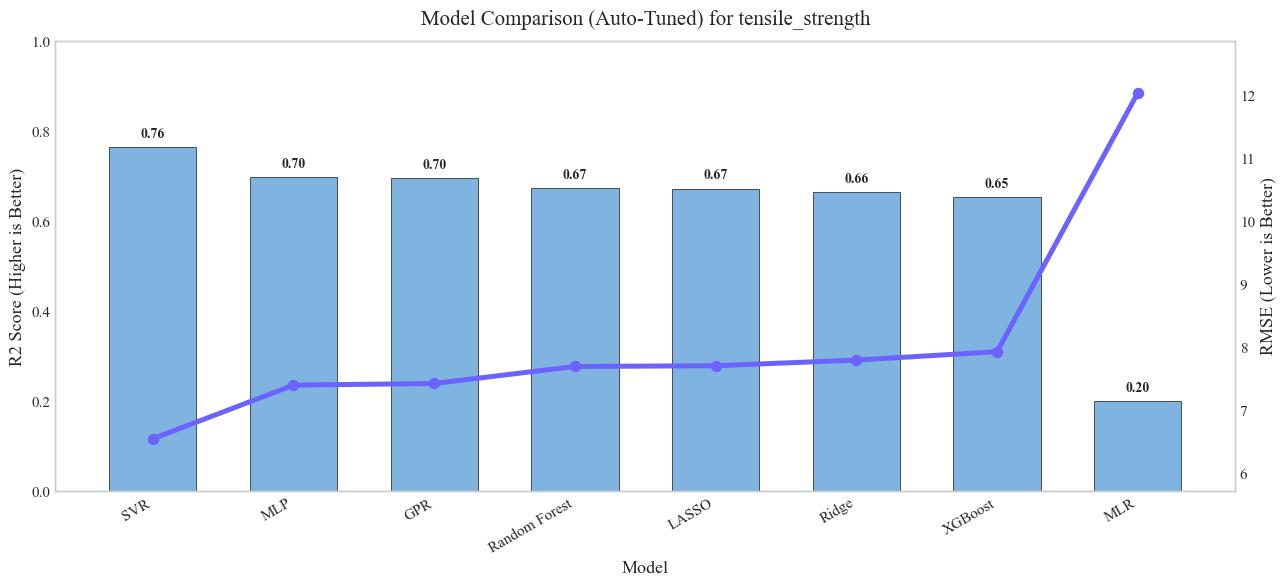


详细排名：
           Model                        Route        R2       RMSE  \
0            SVR   RandomizedSearch(50/210组合)  0.763455   6.540194   
1            MLP   RandomizedSearch(50/320组合)  0.697736   7.393099   
2            GPR             GridSearch(54组合)  0.695597   7.419214   
3  Random Forest   RandomizedSearch(50/720组合)  0.673037   7.689228   
4          LASSO              GridSearch(5组合)  0.672021   7.701162   
5          Ridge              GridSearch(5组合)  0.664328   7.790965   
6        XGBoost  RandomizedSearch(50/8640组合)  0.652742   7.924275   
7            MLR                     NoSearch  0.198754  12.036948   

   Tune_CV_RMSE  
0      6.999308  
1      7.029933  
2      7.306847  
3      7.991854  
4      7.717465  
5      7.772499  
6      8.206727  
7           NaN  


In [31]:
# 多模型能力横向对比（8种算法 + 动态路由自动调参）
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import ParameterGrid

# 设置要预测的目标
current_target = 'tensile_strength'  # 可修改为 'elongation' 或 'healing_eff'
current_features = features_heal if current_target == 'healing_eff' else features_mech

# 获取数据
X, y = get_clean_data(current_target, current_features, df)
print(f"开始自动调参与模型对比，预测目标: {current_target} (样本数: {len(y)})")

# 统一的调参CV（避免 LOOCV 调参过慢）
tune_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 搜索路由阈值：参数组合较少时用 GridSearch，否则用 RandomizedSearch
GRID_THRESHOLD = 60
RANDOM_ITER = 50

# ---------- 定义基础模型 ----------
base_models = {
    "MLR": LinearRegression(),
    "Ridge": make_pipeline(StandardScaler(), Ridge(random_state=42)),
    "LASSO": make_pipeline(StandardScaler(), Lasso(random_state=42, max_iter=20000)),
    "SVR": make_pipeline(StandardScaler(), SVR(kernel='rbf')),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "GPR": make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(
            kernel=1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
            + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            random_state=42
        )
    ),
    "MLP": make_pipeline(StandardScaler(), MLPRegressor(random_state=42, max_iter=5000))
}

# ---------- 定义参数空间 ----------
param_spaces = {
    "MLR": {},
    "Ridge": {
        'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    },
    "LASSO": {
        'lasso__alpha': [0.001, 0.005, 0.01, 0.05, 0.1]
    },
    "SVR": {
        'svr__C': [1, 10, 50, 100, 300, 500, 1000],
        'svr__gamma': ['scale', 0.001, 0.01, 0.1, 0.5, 1.0],
        'svr__epsilon': [0.01, 0.05, 0.1, 0.2, 0.5]
    },
    "Random Forest": {
        'n_estimators': [200, 400, 600, 800],
        'max_depth': [None, 10, 20, 30, 40],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', 0.7, 1.0]
    },
    "XGBoost": {
        'n_estimators': [100, 200, 300, 500],
        'learning_rate': [0.01, 0.02, 0.05, 0.1],
        'max_depth': [3, 4, 5, 6, 8],
        'subsample': [0.6, 0.7, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'reg_alpha': [0.0, 0.1, 1.0],
        'reg_lambda': [1.0, 2.0, 5.0]
    },
    "GPR": {
        'gaussianprocessregressor__kernel': [
            1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=1.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            1.0 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))
        ],
        'gaussianprocessregressor__alpha': [1e-10, 1e-6, 1e-4],
        'gaussianprocessregressor__normalize_y': [True, False],
        'gaussianprocessregressor__n_restarts_optimizer': [0, 5, 10]
    },
    "MLP": {
        'mlpregressor__hidden_layer_sizes': [(32,), (64,), (128,), (64, 32), (128, 64)],
        'mlpregressor__activation': ['relu', 'tanh'],
        'mlpregressor__solver': ['lbfgs', 'adam'],
        'mlpregressor__alpha': [0.0001, 0.001, 0.01, 0.1],
        'mlpregressor__learning_rate_init': [0.0005, 0.001, 0.005, 0.01]
    }
}


def tune_model_with_dynamic_route(model_name, base_model, param_space, X_train, y_train):
    """
    根据参数空间大小，自动选择 GridSearch 或 RandomizedSearch。
    """
    if not param_space:
        print(f" -> {model_name}: 无需调参，直接使用默认模型")
        return base_model, "NoSearch", {}, np.nan

    total_combinations = len(list(ParameterGrid(param_space)))

    if total_combinations <= GRID_THRESHOLD:
        search = GridSearchCV(
            estimator=base_model,
            param_grid=param_space,
            cv=tune_cv,
            scoring='neg_mean_squared_error',
            n_jobs=-1,
            verbose=0
        )
        route = f"GridSearch({total_combinations}组合)"
    else:
        n_iter = min(RANDOM_ITER, total_combinations)
        search = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_space,
            n_iter=n_iter,
            cv=tune_cv,
            scoring='neg_mean_squared_error',
            random_state=42,
            n_jobs=-1,
            verbose=0
        )
        route = f"RandomizedSearch({n_iter}/{total_combinations}组合)"

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_params = search.best_params_
    best_rmse_cv = np.sqrt(-search.best_score_)

    print(f" -> {model_name}: {route} 完成, 调参CV-RMSE={best_rmse_cv:.3f}")
    return best_model, route, best_params, best_rmse_cv


results = []
best_models = {}

for name in base_models.keys():
    tuned_model, route_used, best_params, tune_rmse = tune_model_with_dynamic_route(
        name, base_models[name], param_spaces[name], X, y
    )

    r2, rmse, _ = evaluate_model(tuned_model, X, y)
    best_models[name] = tuned_model

    results.append({
        "Model": name,
        "Route": route_used,
        "R2": r2,
        "RMSE": rmse,
        "Tune_CV_RMSE": tune_rmse,
        "Best_Params": best_params
    })

# ---------- 汇总与排序 ----------
res_df = pd.DataFrame(results).sort_values(by="R2", ascending=False).reset_index(drop=True)

print("\n排序后的模型性能（按 R2）：")
print(res_df[["Model", "Route", "R2", "RMSE", "Tune_CV_RMSE"]])

print("\n各模型最优参数：")
for _, row in res_df.iterrows():
    print(f"\n[{row['Model']}] {row['Route']}")
    print(row["Best_Params"])

# --- 绘图部分（保证柱状图与折线顺序一致） ---
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
fig, ax1 = plt.subplots(figsize=(13, 6))
x_pos = np.arange(len(res_df))

# R2兜底显示：限制在[0, 1]，避免负值影响学术图展示
r2_plot = res_df['R2'].clip(lower=0, upper=1)

# 柱状图：R2（用户指定蓝）
ax1.bar(x_pos, r2_plot, alpha=0.9, width=0.62, color='#71ABDD', edgecolor='black', linewidth=0.5)
ax1.set_xlabel("Model", fontsize=13)
ax1.set_ylabel("R2 Score (Higher is Better)", fontsize=13)
ax1.set_ylim(0, 1.0)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(res_df['Model'], rotation=30, ha='right', fontsize=11)
ax1.tick_params(axis='y', labelsize=11)

for i, r2 in enumerate(r2_plot):
    if r2 > 0:
        ax1.text(i, min(r2 + 0.015, 0.985), f"{r2:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# 右轴：RMSE（协调紫蓝）
ax2 = ax1.twinx()
ax2.plot(x_pos, res_df['RMSE'], marker='o', markersize=7, markeredgewidth=1.2, linewidth=3.6, linestyle='-', color='#6C63FF')
ax2.set_ylabel("RMSE (Lower is Better)", fontsize=13)
ax2.tick_params(axis='y', labelsize=11)
rmse_min, rmse_max = res_df['RMSE'].min(), res_df['RMSE'].max()
pad = (rmse_max - rmse_min) * 0.15 if rmse_max != rmse_min else 1.0
ax2.set_ylim(rmse_min - pad, rmse_max + pad)

plt.title(f"Model Comparison (Auto-Tuned) for {current_target}", fontsize=15, pad=12)
ax1.grid(False)
ax2.grid(False)
fig.tight_layout(pad=1.2)
plt.show()

print("\n详细排名：")
print(res_df[["Model", "Route", "R2", "RMSE", "Tune_CV_RMSE"]])

# 为汇总对比创建别名
res_df_tensile = res_df

In [ ]:
# 多模型能力横向对比: elongation(8种算法 + 动态路由自动调参)

# 设置要预测的目标
current_target = 'elongation'
current_features = features_mech

# 获取数据
X, y = get_clean_data(current_target, current_features, df)
print(f"开始自动调参与模型对比,预测目标: {current_target} (样本数: {len(y)})")

# 复用之前定义的基础模型和参数空间
results_elong = []
best_models_elong = {}

for name in base_models.keys():
    tuned_model, route_used, best_params, tune_rmse = tune_model_with_dynamic_route(
        name, base_models[name], param_spaces[name], X, y
    )
    r2, rmse, _ = evaluate_model(tuned_model, X, y)
    best_models_elong[name] = tuned_model
    results_elong.append({
        "Model": name, "Route": route_used, "R2": r2, "RMSE": rmse,
        "Tune_CV_RMSE": tune_rmse, "Best_Params": best_params
    })

res_df_elong = pd.DataFrame(results_elong).sort_values(by="R2", ascending=False).reset_index(drop=True)
print("\n排序后的模型性能(按 R2):")
print(res_df_elong[["Model", "Route", "R2", "RMSE", "Tune_CV_RMSE"]])

print("\n各模型最优参数:")
for _, row in res_df_elong.iterrows():
    print(f"\n[{row['Model']}] {row['Route']}")
    print(row["Best_Params"])

# 绘图
fig, ax1 = plt.subplots(figsize=(13, 6))
x_pos = np.arange(len(res_df_elong))

# R2兜底显示：限制在[0, 1]，避免负值影响学术图展示
r2_plot = res_df_elong['R2'].clip(lower=0, upper=1)

ax1.bar(x_pos, r2_plot, alpha=0.88, width=0.62, color='#59A14F', edgecolor='black', linewidth=0.5)
ax1.set_xlabel("Model", fontsize=13)
ax1.set_ylabel("R2 Score (Higher is Better)", fontsize=13)
ax1.set_ylim(0, 1.0)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(res_df_elong['Model'], rotation=30, ha='right', fontsize=11)
ax1.tick_params(axis='y', labelsize=11)
for i, r2 in enumerate(r2_plot):
    if r2 > 0:
        ax1.text(i, min(r2 + 0.015, 0.985), f"{r2:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = ax1.twinx()

# RMSE仅用于绘图的兜底显示：截断极端值，保留原始结果表不变
rmse_raw = res_df_elong['RMSE'].copy()
rmse_cap = rmse_raw.nlargest(2).iloc[-1] * 1.05 if len(rmse_raw) > 1 else rmse_raw.max()
rmse_plot = rmse_raw.clip(upper=rmse_cap)
is_capped = rmse_raw > rmse_cap

ax2.plot(x_pos, rmse_plot, marker='o', linewidth=2.0, linestyle='-', color='#D62728')
ax2.set_ylabel("RMSE (Lower is Better)", fontsize=13)
ax2.tick_params(axis='y', labelsize=11)
rmse_min, rmse_max = rmse_plot.min(), rmse_plot.max()
pad = (rmse_max - rmse_min) * 0.15 if rmse_max != rmse_min else 1.0
ax2.set_ylim(rmse_min - pad, rmse_max + pad)

for i, (rmse_disp, rmse_true, capped) in enumerate(zip(rmse_plot, rmse_raw, is_capped)):
    label = f"{rmse_true:.2f}*" if capped else f"{rmse_true:.2f}"
    ax2.text(i, rmse_disp + (pad * 0.03), label, ha='center', va='bottom', color='#B22222', fontsize=10)

if is_capped.any():
    ax2.text(
        0.99, 0.98,
        f"* RMSE capped at {rmse_cap:.2f} for display only",
        transform=ax2.transAxes, ha='right', va='top',
        fontsize=9, color='#8B0000'
    )

plt.title(f"Model Comparison (Auto-Tuned) for {current_target}", fontsize=15, pad=12)
ax1.grid(False)
ax2.grid(False)
fig.tight_layout(pad=1.2)
plt.show()

print("\n详细排名:")
print(res_df_elong[["Model", "Route", "R2", "RMSE", "Tune_CV_RMSE"]])

In [ ]:
# 多模型能力横向对比: healing_eff(8种算法 + 动态路由自动调参)

# 设置要预测的目标
current_target = 'healing_eff'
current_features = features_heal  # 注意: healing_eff 需要包含温度和时间特征

# 获取数据
X, y = get_clean_data(current_target, current_features, df)
print(f"开始自动调参与模型对比,预测目标: {current_target} (样本数: {len(y)})")

# 复用之前定义的基础模型和参数空间
results_heal = []
best_models_heal = {}

for name in base_models.keys():
    tuned_model, route_used, best_params, tune_rmse = tune_model_with_dynamic_route(
        name, base_models[name], param_spaces[name], X, y
    )
    r2, rmse, _ = evaluate_model(tuned_model, X, y)
    best_models_heal[name] = tuned_model
    results_heal.append({
        "Model": name, "Route": route_used, "R2": r2, "RMSE": rmse,
        "Tune_CV_RMSE": tune_rmse, "Best_Params": best_params
    })

res_df_heal = pd.DataFrame(results_heal).sort_values(by="R2", ascending=False).reset_index(drop=True)
print("\n排序后的模型性能(按 R2):")
print(res_df_heal[["Model", "Route", "R2", "RMSE", "Tune_CV_RMSE"]])

print("\n各模型最优参数:")
for _, row in res_df_heal.iterrows():
    print(f"\n[{row['Model']}] {row['Route']}")
    print(row["Best_Params"])

# 绘图
fig, ax1 = plt.subplots(figsize=(13, 6))
x_pos = np.arange(len(res_df_heal))

# R2兜底显示：限制在[0, 1]，避免负值影响学术图展示
r2_plot = res_df_heal['R2'].clip(lower=0, upper=1)

ax1.bar(x_pos, r2_plot, alpha=0.88, width=0.62, color='#F28E2B', edgecolor='black', linewidth=0.5)
ax1.set_xlabel("Model", fontsize=13)
ax1.set_ylabel("R2 Score (Higher is Better)", fontsize=13)
ax1.set_ylim(0, 1.0)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(res_df_heal['Model'], rotation=30, ha='right', fontsize=11)
ax1.tick_params(axis='y', labelsize=11)
for i, r2 in enumerate(r2_plot):
    if r2 > 0:
        ax1.text(i, min(r2 + 0.015, 0.985), f"{r2:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(x_pos, res_df_heal['RMSE'], marker='o', linewidth=2.0, linestyle='-', color='#D62728')
ax2.set_ylabel("RMSE (Lower is Better)", fontsize=13)
ax2.tick_params(axis='y', labelsize=11)
rmse_min, rmse_max = res_df_heal['RMSE'].min(), res_df_heal['RMSE'].max()
pad = (rmse_max - rmse_min) * 0.15 if rmse_max != rmse_min else 1.0
ax2.set_ylim(rmse_min - pad, rmse_max + pad)
for i, rmse in enumerate(res_df_heal['RMSE']):
    ax2.text(i, rmse + (pad * 0.03), f"{rmse:.2f}", ha='center', va='bottom', color='#B22222', fontsize=10)

plt.title(f"Model Comparison (Auto-Tuned) for {current_target}", fontsize=15, pad=12)
ax1.grid(False)
ax2.grid(False)
fig.tight_layout(pad=1.2)
plt.show()

print("\n详细排名:")
print(res_df_heal[["Model", "Route", "R2", "RMSE", "Tune_CV_RMSE"]])

In [ ]:
# ============================================
# 三目标综合对比汇总
# ============================================

# 提取每个目标的前3名模型
summary_data = []

# Tensile Strength 前3名
for idx, row in res_df_tensile.head(3).iterrows():
    summary_data.append({
        '目标': 'tensile_strength',
        '排名': idx+1,
        '模型': row['Model'],
        'R²': row['R2'],
        'RMSE': row['RMSE'],
        '调参路由': row['Route']
    })

# Elongation 前3名
for idx, row in res_df_elong.head(3).iterrows():
    summary_data.append({
        '目标': 'elongation',
        '排名': idx+1,
        '模型': row['Model'],
        'R²': row['R2'],
        'RMSE': row['RMSE'],
        '调参路由': row['Route']
    })

# Healing Efficiency 前3名
for idx, row in res_df_heal.head(3).iterrows():
    summary_data.append({
        '目标': 'healing_eff',
        '排名': idx+1,
        '模型': row['Model'],
        'R²': row['R2'],
        'RMSE': row['RMSE'],
        '调参路由': row['Route']
    })

summary_df = pd.DataFrame(summary_data)

print("="*80)
print("三目标自动调参最优模型综合对比 (Top 3 for Each Target)")
print("="*80)
print(summary_df.to_string(index=False))
print("\n")

# 最优模型总结
print("="*80)
print("各目标最优模型总结")
print("="*80)
print(f"1. [tensile_strength] 最优: {res_df_tensile.iloc[0]['Model']} (R²={res_df_tensile.iloc[0]['R2']:.3f}, RMSE={res_df_tensile.iloc[0]['RMSE']:.2f})")
print(f"2. [elongation]       最优: {res_df_elong.iloc[0]['Model']} (R²={res_df_elong.iloc[0]['R2']:.3f}, RMSE={res_df_elong.iloc[0]['RMSE']:.2f})")
print(f"3. [healing_eff]      最优: {res_df_heal.iloc[0]['Model']} (R²={res_df_heal.iloc[0]['R2']:.3f}, RMSE={res_df_heal.iloc[0]['RMSE']:.2f})")
print("="*80)

In [ ]:
# --- 学术级多模型性能横向比对柱状图 (Train vs 5-Fold CV vs LOOCV) ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, LeaveOneOut
from sklearn.metrics import mean_squared_error
import copy

# 定义需要循环绘制的三个预测目标
targets_info = [
    {'name': 'Tensile Strength', 'target_col': 'tensile_strength', 'features': features_mech},
    {'name': 'Elongation', 'target_col': 'elongation', 'features': features_mech},
    {'name': 'Healing Efficiency', 'target_col': 'healing_eff', 'features': features_heal}
]

# 提取你现有的模型字典
# 为了稳定运行，我们在这里重新实例化确定的模型字典
eval_models = {
    "GPR": make_pipeline(StandardScaler(), GaussianProcessRegressor(
        kernel=1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
        n_restarts_optimizer=10, random_state=42, normalize_y=True)),
    "RF": RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.02, max_depth=5, subsample=0.7, colsample_bytree=0.8, random_state=42, n_jobs=-1),
    "SVR": make_pipeline(StandardScaler(), SVR(C=500, gamma=1.0, epsilon=0.1)),
    "KRR": make_pipeline(StandardScaler(), KernelRidge(kernel='rbf', gamma=0.1, alpha=0.04)),
    "ANN": make_pipeline(StandardScaler(), MLPRegressor(hidden_layer_sizes=(64,), activation='tanh', learning_rate_init=0.001, max_iter=2000, alpha=0.01, random_state=42, solver='lbfgs'))
}

# 按照图片仿制的学术配色
color_train = '#AED6F1'  # 浅蓝
color_cv = '#5DADE2'     # 中蓝
color_test = '#2874A6'   # 深蓝

# 遍历每个目标，画三幅图
for t_info in targets_info:
    t_name = t_info['name']
    t_col = t_info['target_col']
    t_feat = t_info['features']
    
    # 提取并清洗每个目标独立的数据
    try:
        X_cur, y_cur = get_clean_data(t_col, t_feat, df)
    except Exception as e:
        print(f"提取 {t_name} 数据失败，跳过。错误: {e}")
        continue
        
    model_names = list(eval_models.keys())
    train_rmses = []
    cv_rmses = []
    cv_stds = []
    loocv_rmses = []
    
    print(f"正在评估并绘制 {t_name} 的性能对比图...")
    
    # 针对各种模型收集指标
    for m_name, model_template in eval_models.items():
        # 克隆独立模型防止互相影响
        from sklearn.base import clone
        model = clone(model_template)
        
        # 1. 训练集 RMSE
        model.fit(X_cur, y_cur)
        y_train_pred = model.predict(X_cur)
        train_rmse = np.sqrt(mean_squared_error(y_cur, y_train_pred))
        train_rmses.append(train_rmse)
        
        # 2. 5折交叉验证 RMSE (以计算 Error Bars 误差棒)
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(model, X_cur, y_cur, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
        rmse_scores = -scores
        cv_rmses.append(np.mean(rmse_scores))
        cv_stds.append(np.std(rmse_scores)) # 误差棒使用标准差
        
        # 3. LOOCV RMSE (作为 Test RMSE / 最终泛化性能)
        loo = LeaveOneOut()
        y_loocv_pred = cross_val_predict(model, X_cur, y_cur, cv=loo, n_jobs=-1)
        loocv_rmse = np.sqrt(mean_squared_error(y_cur, y_loocv_pred))
        loocv_rmses.append(loocv_rmse)

    # 按 LOOCV RMSE 从低到高排序（左 -> 右）
    sort_idx = np.argsort(loocv_rmses)
    model_names = [model_names[i] for i in sort_idx]
    train_rmses = [train_rmses[i] for i in sort_idx]
    cv_rmses = [cv_rmses[i] for i in sort_idx]
    cv_stds = [cv_stds[i] for i in sort_idx]
    loocv_rmses = [loocv_rmses[i] for i in sort_idx]
    
    # -------- 开始作图 --------
    fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
    
    x_pos = np.arange(len(model_names))
    width = 0.25  # 让出三根柱子的宽度
    
    # 绘制三组柱子
    rects1 = ax.bar(x_pos - width, train_rmses, width, label='Train RMSE', 
                    color=color_train, edgecolor='black', linewidth=1, zorder=3)
                    
    rects2 = ax.bar(x_pos, cv_rmses, width, yerr=cv_stds, label='CV RMSE (5-fold)', 
                    color=color_cv, edgecolor='black', linewidth=1, 
                    capsize=5, ecolor='black', zorder=3)
                    
    rects3 = ax.bar(x_pos + width, loocv_rmses, width, label='LOOCV RMSE (Test)', 
                    color=color_test, edgecolor='black', linewidth=1, zorder=3)
    
    # 美化轴和标签
    ax.set_ylabel(f'{t_name} RMSE', fontsize=12, fontweight='bold')
    ax.set_title(f'Model Performance Comparison ({t_name})\n(Ordered by LOOCV RMSE: low → high)', fontsize=14, fontweight='bold', pad=15)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_names, fontsize=12, fontweight='bold')
    
    # 移除顶部和右侧的边框以贴合学术风格
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # 增加网格线 (仅 Y 轴)
    ax.yaxis.grid(True, linestyle=(0, (5, 5)), alpha=0.5, color='gray', zorder=0)
    
    # 图例配置
    ax.legend(fontsize=11, frameon=True, shadow=False, edgecolor='black')
    
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================
# 一图决策（纯图版）：RMSE + R2（无表格，主图显示全部8个算法）
# 严格优先使用前面对比单元结果：res_df_tensile（SVR≈0.76）
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) 目标切换
decision_target = 'tensile_strength'  # 'elongation' / 'healing_eff'

# 2) 读取前面单元的结果表（优先顺序非常严格）
def _pick_result_df(target_name: str):
    if target_name == 'tensile_strength':
        if 'res_df_tensile' in globals() and isinstance(res_df_tensile, pd.DataFrame):
            return res_df_tensile[['Model', 'R2', 'RMSE']].copy(), 'res_df_tensile'
        if 'res_df' in globals() and isinstance(res_df, pd.DataFrame):
            tmp = res_df.copy()
            needed_cols = {'Model', 'R2', 'RMSE'}
            model_set = set(tmp['Model'].astype(str).tolist()) if 'Model' in tmp.columns else set()
            if needed_cols.issubset(tmp.columns) and {'MLR', 'Ridge', 'LASSO', 'SVR'}.issubset(model_set):
                return tmp[['Model', 'R2', 'RMSE']].copy(), 'res_df'
        raise ValueError('未检测到 tensile 的自动调参结果表。请先运行第20格（多模型自动调参）后再运行本格。')

    if target_name == 'elongation':
        if 'res_df_elong' in globals() and isinstance(res_df_elong, pd.DataFrame):
            return res_df_elong[['Model', 'R2', 'RMSE']].copy(), 'res_df_elong'
        raise ValueError('未检测到 elongation 结果表。请先运行第21格后再运行本格。')

    if target_name == 'healing_eff':
        if 'res_df_heal' in globals() and isinstance(res_df_heal, pd.DataFrame):
            return res_df_heal[['Model', 'R2', 'RMSE']].copy(), 'res_df_heal'
        raise ValueError('未检测到 healing_eff 结果表。请先运行第22格后再运行本格。')

    raise ValueError(f'未知目标: {target_name}')

res_dec, source_name = _pick_result_df(decision_target)

# 3) 计算综合分（R2高 + RMSE低）
w_r2, w_rmse = 0.55, 0.45
r2_min, r2_max = res_dec['R2'].min(), res_dec['R2'].max()
rmse_min, rmse_max = res_dec['RMSE'].min(), res_dec['RMSE'].max()

res_dec['R2_norm'] = 1.0 if np.isclose(r2_max, r2_min) else (res_dec['R2'] - r2_min) / (r2_max - r2_min)
res_dec['RMSE_norm'] = 1.0 if np.isclose(rmse_max, rmse_min) else (rmse_max - res_dec['RMSE']) / (rmse_max - rmse_min)
res_dec['Score'] = w_r2 * res_dec['R2_norm'] + w_rmse * res_dec['RMSE_norm']

res_dec = res_dec.sort_values('Score', ascending=False).reset_index(drop=True)
res_dec['Rank'] = np.arange(1, len(res_dec) + 1)
best_row = res_dec.iloc[0]

# 4) 仅用于视觉辅助：标记离群，但不隐藏任何点
q1_rmse, q3_rmse = res_dec['RMSE'].quantile([0.25, 0.75])
iqr_rmse = q3_rmse - q1_rmse
rmse_upper = q3_rmse + 1.5 * iqr_rmse

q1_r2, q3_r2 = res_dec['R2'].quantile([0.25, 0.75])
iqr_r2 = q3_r2 - q1_r2
r2_lower = q1_r2 - 1.5 * iqr_r2

res_dec['is_outlier'] = (res_dec['RMSE'] > rmse_upper) | (res_dec['R2'] < r2_lower)

# 5) 主图：显示全部8个算法
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10.6, 7.0), dpi=140)

main_df = res_dec[~res_dec['is_outlier']].copy()
out_df = res_dec[res_dec['is_outlier']].copy()

# 非离群点
if len(main_df) > 0:
    ax.scatter(main_df['RMSE'], main_df['R2'], s=145, c='#4C78A8', edgecolors='black', linewidths=0.95, zorder=3)

# 离群点（仍在主图显示，只是换色）
if len(out_df) > 0:
    ax.scatter(out_df['RMSE'], out_df['R2'], s=155, c='#F28E2B', edgecolors='black', linewidths=0.95, zorder=3)

# 所有点都标 rank 数字
for _, row in res_dec.iterrows():
    txt_color = 'white' if not row['is_outlier'] else 'black'
    ax.text(row['RMSE'], row['R2'], str(int(row['Rank'])), ha='center', va='center',
            color=txt_color, fontsize=9, fontweight='bold', zorder=4)

# 推荐点高亮
ax.scatter(best_row['RMSE'], best_row['R2'], s=280, marker='*', c='crimson', edgecolors='black', linewidths=0.95, zorder=5)
ax.annotate(
    f"Recommended #{int(best_row['Rank'])}: {best_row['Model']}\nR2={best_row['R2']:.3f}, RMSE={best_row['RMSE']:.3f}",
    xy=(best_row['RMSE'], best_row['R2']),
    xytext=(24, 24),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', lw=1.8, color='crimson'),
    fontsize=10.5,
    color='crimson',
    bbox=dict(boxstyle='round,pad=0.28', fc='white', ec='crimson', alpha=0.95)
)

# 坐标范围基于“全部点”，确保1-8全部可见
x_min, x_max = res_dec['RMSE'].min(), res_dec['RMSE'].max()
y_min, y_max = res_dec['R2'].min(), res_dec['R2'].max()
x_pad = (x_max - x_min) * 0.10 if x_max > x_min else 0.5
y_pad = (y_max - y_min) * 0.10 if y_max > y_min else 0.05
ax.set_xlim(max(0, x_min - x_pad), x_max + x_pad)
ax.set_ylim(y_min - y_pad, y_max + y_pad)

# 图例（简洁）
legend_items = []
if len(main_df) > 0:
    legend_items.append(plt.Line2D([0], [0], marker='o', color='w', label='Regular Models', markerfacecolor='#4C78A8', markeredgecolor='black', markersize=8))
if len(out_df) > 0:
    legend_items.append(plt.Line2D([0], [0], marker='o', color='w', label='Outlier Models', markerfacecolor='#F28E2B', markeredgecolor='black', markersize=8))
legend_items.append(plt.Line2D([0], [0], marker='*', color='w', label='Recommended', markerfacecolor='crimson', markeredgecolor='black', markersize=12))
ax.legend(handles=legend_items, loc='best', fontsize=9)

ax.set_title(f"Model Selection Map ({decision_target})\n(LOOCV R2 vs LOOCV RMSE)", fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('RMSE (lower is better)', fontsize=12, fontweight='bold')
ax.set_ylabel('R2 (higher is better)', fontsize=12, fontweight='bold')
ax.grid(True, linestyle=(0, (4, 5)), alpha=0.45)

plt.tight_layout()
plt.show()

# 6) 控制台确认
print(f"\nTarget: {decision_target}")
print(f"Source: {source_name}")
print(f"Recommended model: {best_row['Model']}")
print(res_dec[['Rank', 'Model', 'R2', 'RMSE', 'Score']].round(4))

In [ ]:
 # ============================================
# 三目标：最优算法在分层特征输入下的 R2 与拟合曲线
# elongation: level1 / level1+level2 / level1+level2+level3
# healing:    level1 / level1+level2 / level1+level2+level3+process (即 1/2/4 阶段)
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, RBF
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor


verified_best_models = {
    'tensile_strength': 'SVR',
    'elongation': 'XGBoost',
    'healing_eff': 'GPR'
}


def build_model_by_name(model_name: str):
    name = str(model_name).strip()
    if name == 'MLR':
        return LinearRegression()
    if name == 'Ridge':
        return make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=42))
    if name in ['LASSO', 'Lasso']:
        return make_pipeline(StandardScaler(), Lasso(alpha=0.01, random_state=42, max_iter=20000))
    if name == 'SVR':
        return make_pipeline(StandardScaler(), SVR(C=500, gamma=1.0, epsilon=0.1, kernel='rbf'))
    if name in ['Random Forest', 'RF']:
        return RandomForestRegressor(n_estimators=400, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1)
    if name == 'XGBoost':
        return XGBRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1
        )
    if name == 'GPR':
        kernel = 1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) + \
                 WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))
        return make_pipeline(
            StandardScaler(),
            GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=42, n_restarts_optimizer=5)
        )
    if name in ['MLP', 'ANN']:
        return make_pipeline(
            StandardScaler(),
            MLPRegressor(hidden_layer_sizes=(64,), activation='tanh', solver='lbfgs', alpha=0.01, max_iter=3000, random_state=42)
        )
    raise ValueError(f'未知模型名: {name}')


def get_best_model_name_for_target(target_col: str):
    if target_col == 'tensile_strength' and 'res_df_tensile' in globals() and isinstance(res_df_tensile, pd.DataFrame):
        return res_df_tensile.sort_values('R2', ascending=False).iloc[0]['Model']
    if target_col == 'elongation' and 'res_df_elong' in globals() and isinstance(res_df_elong, pd.DataFrame):
        return res_df_elong.sort_values('R2', ascending=False).iloc[0]['Model']
    if target_col == 'healing_eff' and 'res_df_heal' in globals() and isinstance(res_df_heal, pd.DataFrame):
        return res_df_heal.sort_values('R2', ascending=False).iloc[0]['Model']
    return verified_best_models[target_col]


def get_best_model_estimator_for_target(target_col: str, best_model_name: str):
    if target_col == 'tensile_strength' and 'best_models' in globals() and isinstance(best_models, dict):
        if best_model_name in best_models:
            return clone(best_models[best_model_name])
    if target_col == 'elongation' and 'best_models_elong' in globals() and isinstance(best_models_elong, dict):
        if best_model_name in best_models_elong:
            return clone(best_models_elong[best_model_name])
    if target_col == 'healing_eff' and 'best_models_heal' in globals() and isinstance(best_models_heal, dict):
        if best_model_name in best_models_heal:
            return clone(best_models_heal[best_model_name])
    return build_model_by_name(best_model_name)


def evaluate_loocv(model, X, y):
    y_pred = cross_val_predict(model, X, y, cv=LeaveOneOut(), n_jobs=-1)
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    return r2, rmse, y_pred


lvl1 = features_mech[:5]
lvl2 = features_mech[5:9]
lvl3 = features_mech[9:]

analysis_targets = [
    ('Tensile Strength', 'tensile_strength'),
    ('Elongation', 'elongation'),
    ('Healing Efficiency', 'healing_eff')
]

layer_results_all = []

for target_name, target_col in analysis_targets:
    best_model_name = get_best_model_name_for_target(target_col)

    if target_col == 'healing_eff':
        feature_levels = [
            ('level1', lvl1),
            ('level1+level2', lvl1 + lvl2),
            ('level1+level2+level3+process', lvl1 + lvl2 + lvl3 + ['healing_temperature', 'healing_time'])
        ]
    else:
        feature_levels = [
            ('level1', lvl1),
            ('level1+level2', lvl1 + lvl2),
            ('level1+level2+level3', lvl1 + lvl2 + lvl3)
        ]

    print(f"\n{'='*90}")
    print(f"目标: {target_name} | 采用最优算法: {best_model_name}")
    print(f"{'='*90}")

    per_level = []

    for level_label, feat_list in feature_levels:
        X_cur, y_cur = get_clean_data(target_col, feat_list, df)
        model = get_best_model_estimator_for_target(target_col, best_model_name)
        r2, rmse, y_pred = evaluate_loocv(model, X_cur, y_cur)

        rec = {
            'Target': target_name,
            'TargetCol': target_col,
            'BestModel': best_model_name,
            'Level': level_label,
            'NumFeatures': len(feat_list),
            'R2': r2,
            'RMSE': rmse,
            'y_true': y_cur,
            'y_pred': y_pred
        }
        per_level.append(rec)
        layer_results_all.append({k: v for k, v in rec.items() if k not in ['y_true', 'y_pred']})

        print(f"{level_label:<30} | 特征数={len(feat_list):>2d} | R2={r2:>7.4f} | RMSE={rmse:>9.4f}")

    n_levels = len(per_level)
    fig = plt.figure(figsize=(6 * n_levels, 10), dpi=130)
    gs = fig.add_gridspec(2, n_levels, height_ratios=[1.0, 2.0])

    ax_bar = fig.add_subplot(gs[0, :])
    level_labels = [x['Level'] for x in per_level]
    r2_vals = [x['R2'] for x in per_level]

    bar_colors = ['#9ecae1', '#4292c6', '#08519c']

    bars = ax_bar.bar(level_labels, r2_vals, color=bar_colors[:n_levels], edgecolor='black', linewidth=1.0)
    ax_bar.set_ylabel('LOOCV R2', fontsize=12, fontweight='bold')
    ax_bar.set_title(f'{target_name} | Best Algorithm: {best_model_name} | R2 across Feature Levels', fontsize=14, fontweight='bold')
    ax_bar.grid(axis='y', linestyle=(0, (4, 5)), alpha=0.4)

    r2_min, r2_max = min(r2_vals), max(r2_vals)
    pad = max(0.05, (r2_max - r2_min) * 0.4)
    ax_bar.set_ylim(r2_min - pad, min(1.02, r2_max + pad * 0.2))

    for b, v in zip(bars, r2_vals):
        ax_bar.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    for i, rec in enumerate(per_level):
        ax = fig.add_subplot(gs[1, i])
        y_true = rec['y_true']
        y_pred = rec['y_pred']

        y_min = min(np.min(y_true), np.min(y_pred))
        y_max = max(np.max(y_true), np.max(y_pred))
        line_x = np.linspace(y_min, y_max, 200)

        ax.scatter(y_true, y_pred, s=55, alpha=0.75, c=bar_colors[i], edgecolors='black', linewidths=0.5)
        ax.plot(line_x, line_x, 'r--', linewidth=1.8)

        if len(y_true) > 1:
            k, b = np.polyfit(y_true, y_pred, 1)
            ax.plot(line_x, k * line_x + b, color='black', linewidth=1.6)

        ax.set_title(f"{rec['Level']}\nR2={rec['R2']:.3f}, RMSE={rec['RMSE']:.3f}", fontsize=11, fontweight='bold')
        ax.set_xlabel('Measured', fontsize=10)
        ax.set_ylabel('Predicted', fontsize=10)
        ax.grid(alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

layer_results_df = pd.DataFrame(layer_results_all)
print("\n分层特征评估汇总：")
print(layer_results_df.round(4))

[Tensile Strength | SVR] SHAP计算中... (模型来源: 上方最优模型对象)
  最优参数: {'svr__gamma': 0.01, 'svr__epsilon': 0.1, 'svr__C': 100}


100%|██████████| 84/84 [00:02<00:00, 32.72it/s]
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHe

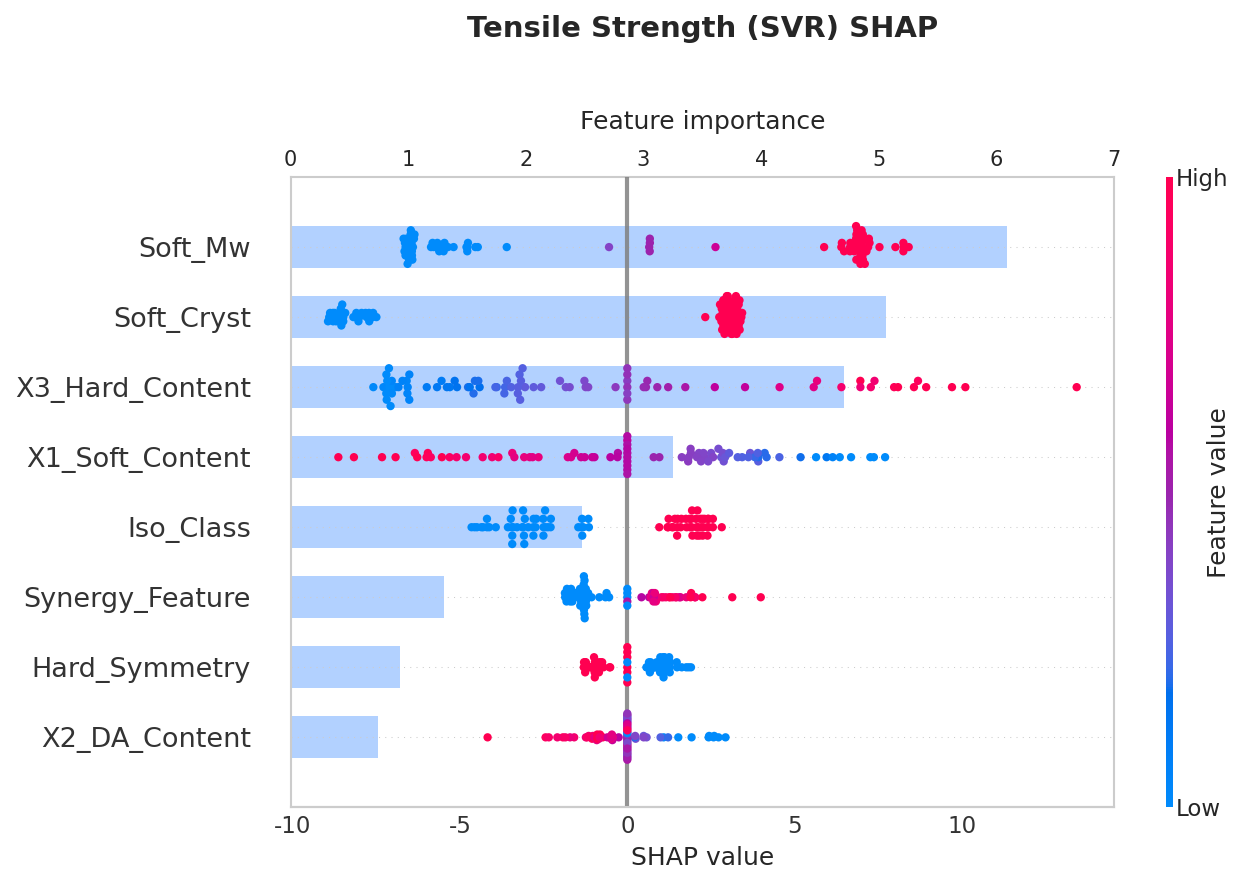

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

[Elongation | XGBoost] SHAP计算中... (模型来源: 上方最优模型对象)
  最优参数: {'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.02, 'colsample_bytree': 0.6}


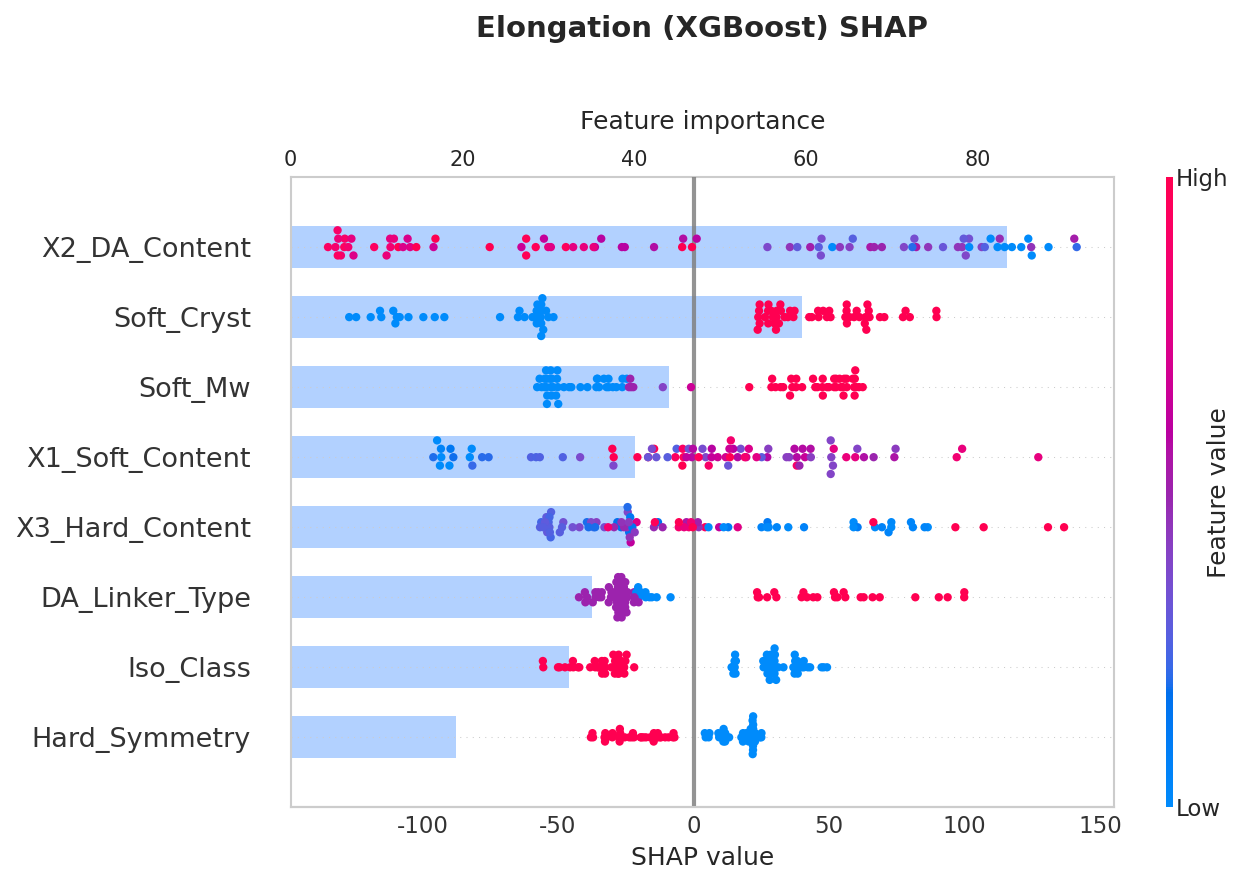

[Healing Efficiency | GPR] SHAP计算中... (模型来源: 上方最优模型对象)
  最优参数: {'gaussianprocessregressor__alpha': 0.0001, 'gaussianprocessregressor__kernel': 1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=0.1), 'gaussianprocessregressor__n_restarts_optimizer': 0, 'gaussianprocessregressor__normalize_y': False}


100%|██████████| 37/37 [00:00<00:00, 81.28it/s]
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHe

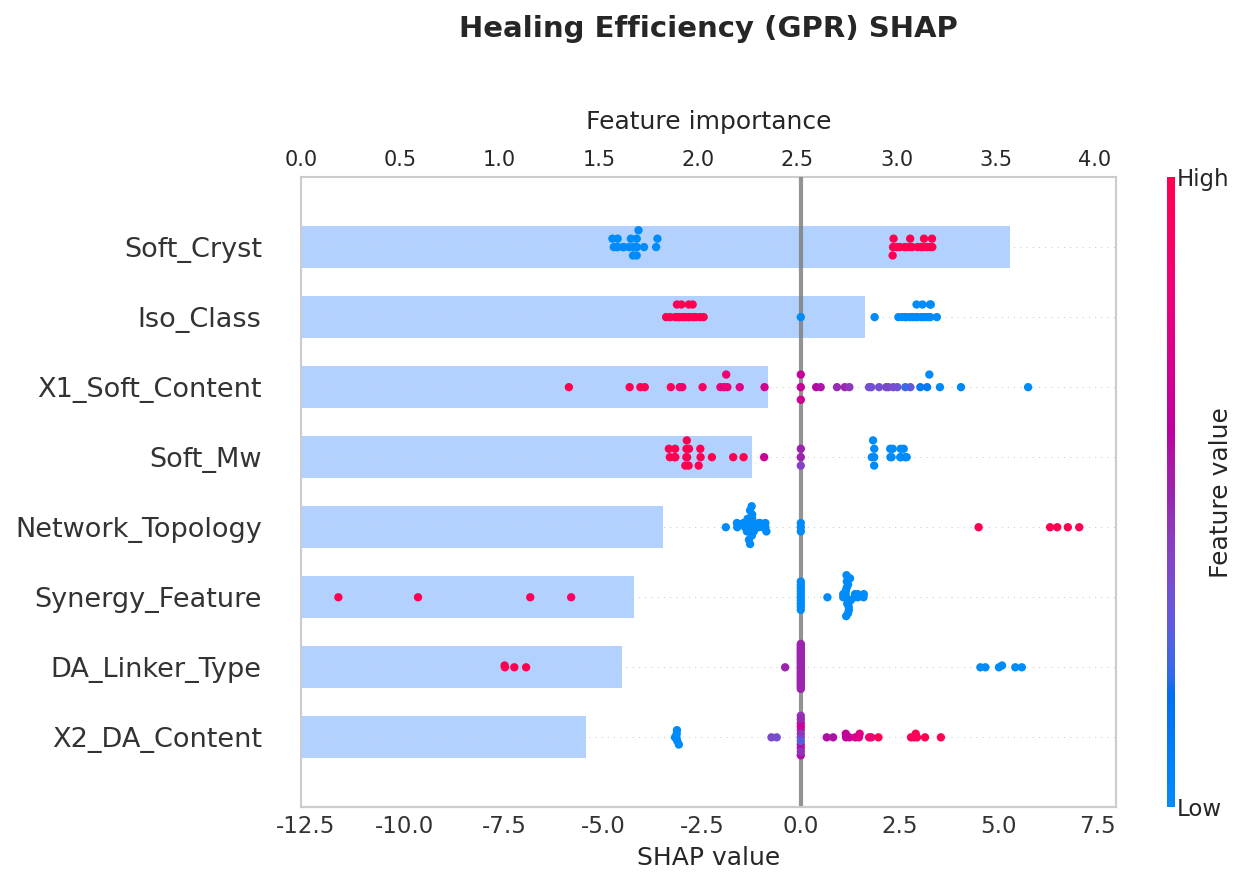

In [28]:
# ============================================
# 按要求绘制 SHAP 散点图 + 底部条形图 (Top 8 特征)
# 最优算法（严格来自上方单元最优结果）对应三个目标
# ============================================
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone

import warnings
warnings.filterwarnings('ignore')

# 使用数据集
df_all = pd.read_csv('Final_Features_Ultimate_all_deletion.csv')

features_mech_all = [
    'X1_Soft_Content', 'X2_DA_Content', 'X3_Hard_Content', 'X4_R_Ratio', 'X5_Add_Crosslink',
    'DA_Linker_Type', 'Network_Topology', 'Polyol_Class', 'Iso_Class',
    'Soft_Mw', 'Constraint_Factor', 'Hard_Symmetry', 'Soft_Cryst', 'Synergy_Feature'
]
features_heal_all = features_mech_all + ['healing_temperature', 'healing_time']

def get_clean_data_local(target_col, feature_cols):
    d = df_all.dropna(subset=[target_col] + feature_cols).copy()
    return d[feature_cols].copy(), d[target_col].values


def extract_best_params(best_row):
    for col in ['Best_Params', 'Params', 'best_params']:
        if col in best_row.index:
            return best_row[col]
    return 'N/A'


def get_best_from_upper_cells_strict(target_col):
    if target_col == 'tensile_strength':
        df_res = res_df_tensile if 'res_df_tensile' in globals() and isinstance(res_df_tensile, pd.DataFrame) else (
            res_df if 'res_df' in globals() and isinstance(res_df, pd.DataFrame) else None
        )
        model_bank = best_models if 'best_models' in globals() and isinstance(best_models, dict) else None
    elif target_col == 'elongation':
        df_res = res_df_elong if 'res_df_elong' in globals() and isinstance(res_df_elong, pd.DataFrame) else None
        model_bank = best_models_elong if 'best_models_elong' in globals() and isinstance(best_models_elong, dict) else None
    else:
        df_res = res_df_heal if 'res_df_heal' in globals() and isinstance(res_df_heal, pd.DataFrame) else None
        model_bank = best_models_heal if 'best_models_heal' in globals() and isinstance(best_models_heal, dict) else None

    if df_res is None or model_bank is None or len(df_res) == 0:
        raise RuntimeError(f"{target_col}: 未找到上方最优结果表或最优模型对象，请先运行调参与最优模型单元。")

    best_row = df_res.sort_values('R2', ascending=False).iloc[0]
    best_name = str(best_row['Model'])

    if best_name not in model_bank:
        raise RuntimeError(f"{target_col}: 最优模型 {best_name} 不在最优模型对象字典中，请先完整运行上方单元。")

    best_params = extract_best_params(best_row)
    return best_name, clone(model_bank[best_name]), best_params


targets_list = [
    ('Tensile Strength', 'tensile_strength', features_mech_all),
    ('Elongation', 'elongation', features_mech_all),
    ('Healing Efficiency', 'healing_eff', features_heal_all),
]

for target_name, target_col, feats in targets_list:
    X_df, y = get_clean_data_local(target_col, feats)
    mname, model, best_params = get_best_from_upper_cells_strict(target_col)

    model.fit(X_df.values, y)

    print(f"[{target_name} | {mname}] SHAP计算中... (模型来源: 上方最优模型对象)")
    print(f"  最优参数: {best_params}")

    if mname == 'XGBoost':
        exp_xg = shap.TreeExplainer(model)
        vals = exp_xg.shap_values(X_df)
    elif mname == 'SVR':
        scaler = model.named_steps['standardscaler']
        svr_model = model.named_steps['svr']
        X_scaled = scaler.transform(X_df.values)
        X_train_summary = shap.kmeans(X_scaled, k=30).data
        exp_svr = shap.KernelExplainer(svr_model.predict, X_train_summary)
        vals = exp_svr.shap_values(X_scaled, nsamples=400)
    elif mname == 'GPR':
        scaler = model.named_steps['standardscaler']
        gpr_model = model.named_steps['gaussianprocessregressor']
        X_scaled = scaler.transform(X_df.values)
        X_train_summary = shap.kmeans(X_scaled, k=30).data
        exp_gpr = shap.KernelExplainer(gpr_model.predict, X_train_summary)
        vals = exp_gpr.shap_values(X_scaled, nsamples=400)
    else:
        exp = shap.Explainer(model.predict, X_df)
        exp_vals = exp(X_df)
        vals = exp_vals.values

    if len(vals.shape) == 3:
        vals = vals[:, :, 0]

    mean_abs = np.abs(vals).mean(axis=0)

    top_idx = np.argsort(mean_abs)[::-1][:8]
    X_top = X_df.iloc[:, top_idx]
    vals_top = vals[:, top_idx]

    mean_abs_dict = {feat: val for feat, val in zip(X_df.columns[top_idx], mean_abs[top_idx])}

    plt.close('all')
    fig = plt.figure(figsize=(9, 6), dpi=150)

    shap.summary_plot(vals_top, X_top, show=False, plot_size=None)

    ax1 = plt.gca()
    ax1.set_xlabel('SHAP value', fontsize=12)

    ax1.tick_params(axis='y', pad=-1)

    for line in list(ax1.lines):
        xd = line.get_xdata()
        if hasattr(xd, '__len__') and len(xd) >= 2:
            if np.allclose(np.asarray(xd, dtype=float), float(xd[0])):
                line.remove()

    ax1.grid(False)
    ax1.xaxis.grid(False)
    ax1.yaxis.grid(False)

    ax1.axvline(0, color='gray', linewidth=2.0, alpha=0.85, zorder=1)

    yticklabels = [t.get_text() for t in ax1.get_yticklabels()]
    bar_lengths = [mean_abs_dict[name] for name in yticklabels]
    y_pos = np.arange(len(yticklabels))

    ax2 = ax1.twiny()

    ax2.barh(y_pos, bar_lengths, color='#7FB3FF', alpha=0.6, height=0.6, align='center', zorder=-1)

    ax2.set_xlabel('Feature importance', fontsize=12, labelpad=10)
    ax2.xaxis.set_label_position('top')
    ax2.xaxis.tick_top()
    ax2.set_xlim(0, max(bar_lengths) * 1.15)

    ax2.grid(False)
    ax2.xaxis.grid(False)
    ax2.yaxis.grid(False)

    ax1.patch.set_visible(False)
    ax1.set_zorder(ax2.get_zorder() + 1)

    for cax in fig.axes:
        if cax is not ax1 and cax is not ax2:
            if isinstance(cax.get_ylabel(), str) and 'Feature value' in cax.get_ylabel():
                cax.set_ylabel('Feature value', rotation=90, fontsize=12, labelpad=-10)
                cax.yaxis.set_label_position('right')
                cax.tick_params(axis='y', pad=1)

    plt.title(f"{target_name} ({mname}) SHAP", pad=35, fontsize=14, loc='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

In [26]:
# 逐项核对：特征 / 最优算法 / 参数是否与上方最优解一致（基于当前第17单元实际取模逻辑）
import numpy as np
import pandas as pd


def _pick_best_row(target_col):
    if target_col == 'tensile_strength':
        if 'res_df_tensile' in globals() and isinstance(res_df_tensile, pd.DataFrame):
            return res_df_tensile.sort_values('R2', ascending=False).iloc[0]
        if 'res_df' in globals() and isinstance(res_df, pd.DataFrame):
            return res_df.sort_values('R2', ascending=False).iloc[0]
    if target_col == 'elongation' and 'res_df_elong' in globals() and isinstance(res_df_elong, pd.DataFrame):
        return res_df_elong.sort_values('R2', ascending=False).iloc[0]
    if target_col == 'healing_eff' and 'res_df_heal' in globals() and isinstance(res_df_heal, pd.DataFrame):
        return res_df_heal.sort_values('R2', ascending=False).iloc[0]
    return None


def _pick_best_model_obj(target_col, best_name):
    if target_col == 'tensile_strength' and 'best_models' in globals() and isinstance(best_models, dict):
        return best_models.get(best_name, None)
    if target_col == 'elongation' and 'best_models_elong' in globals() and isinstance(best_models_elong, dict):
        return best_models_elong.get(best_name, None)
    if target_col == 'healing_eff' and 'best_models_heal' in globals() and isinstance(best_models_heal, dict):
        return best_models_heal.get(best_name, None)
    return None


def _extract_key_params(model_name, model_obj):
    if model_obj is None:
        return {}
    params = model_obj.get_params()
    if model_name == 'SVR':
        return {
            'svr__C': params.get('svr__C'),
            'svr__gamma': params.get('svr__gamma'),
            'svr__epsilon': params.get('svr__epsilon'),
            'svr__kernel': params.get('svr__kernel'),
        }
    if model_name == 'XGBoost':
        keys = ['n_estimators', 'learning_rate', 'max_depth', 'subsample', 'colsample_bytree', 'reg_alpha', 'reg_lambda']
        return {k: params.get(k) for k in keys}
    if model_name == 'GPR':
        keys = ['gaussianprocessregressor__kernel', 'gaussianprocessregressor__alpha',
                'gaussianprocessregressor__normalize_y', 'gaussianprocessregressor__n_restarts_optimizer']
        return {k: params.get(k) for k in keys}
    return {}


checks = [
    ('tensile_strength', features_mech),
    ('elongation', features_mech),
    ('healing_eff', features_heal),
]

print('=' * 120)
print('逐项核对：特征、最优模型、参数（上方单元最优解 vs 第17单元当前实际使用）')
print('=' * 120)

for target_col, expected_features in checks:
    print(f"\n>>> 目标: {target_col}")

    # A) 特征核对
    shap_feats = features_heal_all if target_col == 'healing_eff' else features_mech_all
    feature_ok = (list(expected_features) == list(shap_feats))
    print(f"[特征一致性] {'✅ 一致' if feature_ok else '❌ 不一致'} | 期望={len(expected_features)}个, SHAP单元={len(shap_feats)}个")

    # B) 最优模型名核对
    best_row = _pick_best_row(target_col)
    if best_row is None:
        print('[最优模型] ❌ 未找到上方结果表，请先运行多模型对比单元')
        continue

    best_name = str(best_row['Model'])
    shap_name, shap_model, shap_source = get_best_from_upper_cells(target_col)
    name_ok = (best_name == shap_name)
    print(f"[最优模型名] {'✅ 一致' if name_ok else '❌ 不一致'} | 上方={best_name}, 第17单元={shap_name} ({shap_source})")

    # C) 参数核对
    tuned_model_obj = _pick_best_model_obj(target_col, best_name)
    tuned_params = _extract_key_params(best_name, tuned_model_obj)
    shap_params = _extract_key_params(shap_name, shap_model)

    if len(tuned_params) == 0:
        print('[参数一致性] ⚠️ 无法从上方最优模型对象提取参数（可能上方单元尚未执行）')
    else:
        diffs = []
        for k in tuned_params.keys():
            a = tuned_params.get(k)
            b = shap_params.get(k)
            same = (str(a) == str(b))
            if not same:
                diffs.append((k, a, b))

        if len(diffs) == 0:
            print('[参数一致性] ✅ 一致')
        else:
            print('[参数一致性] ❌ 不一致，差异如下:')
            for k, a, b in diffs:
                print(f'  - {k}: 上方={a} | 第17单元={b}')

print('\n核对完成。')

逐项核对：特征、最优模型、参数（上方单元最优解 vs 第17单元当前实际使用）

>>> 目标: tensile_strength
[特征一致性] ✅ 一致 | 期望=14个, SHAP单元=14个
[最优模型名] ✅ 一致 | 上方=SVR, 第17单元=SVR (上方最优模型对象)
[参数一致性] ✅ 一致

>>> 目标: elongation
[特征一致性] ✅ 一致 | 期望=14个, SHAP单元=14个
[最优模型名] ✅ 一致 | 上方=XGBoost, 第17单元=XGBoost (上方最优模型对象)
[参数一致性] ✅ 一致

>>> 目标: healing_eff
[特征一致性] ✅ 一致 | 期望=16个, SHAP单元=16个
[最优模型名] ✅ 一致 | 上方=GPR, 第17单元=GPR (上方最优模型对象)
[参数一致性] ✅ 一致

核对完成。
